# Universal Adapters in MalthusJAX

One of the most powerful features of MalthusJAX is the `UniversalAdapterEngine`. 
It abstracts away the implementation details of various evolutionary computation libraries, 
allowing you to hot-swap them using identical hyperparameters and APIs.

In this notebook, we'll demonstrate comparing:
1. Our Native Genetic Algorithm
2. EvoSAX (Differential Evolution)
3. QDAX (MAP-Elites - a Quality Diversity algorithm)

All competing head-to-head on the exact same problem!

In [1]:
import os
from pathlib import Path

# If running as a notebook in examples/showcase, change directory to the repository root
if Path(os.getcwd()).name == "showcase":
    os.chdir("../..")
print(f"Working Directory: {os.getcwd()}")

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import pandas as pd

from malthusjax.composer.composer import Composer

Working Directory: /Users/leonardodicaterina/Documents/GitHub/MalthusJAX


## 1. Setting up the Comparison

We'll use `Composer.compare()`. We can pass a `shared_kwargs` dictionary for parameters that all pipelines should share, and a dictionary of pipeline-specific parameters.

In [2]:
composer = Composer()

shared_kwargs = {
    "genome": "real",
    "genome_length": 5,
    "fitness": "bbob:fn_name=rastrigin,num_dims=5", # Rastrigin in 5D
    "pop_size": 256,
    "generations": 50,
    "maximize": False,
    "seed": 1337
}

pipelines = {
    # 1. Native JAX GA
    "Native GA": {
        "backend": "malthusjax",
        "selection": "tournament:tournament_size=3",
        "crossover": "uniform_real:crossover_rate=0.5",
        "mutation": "gaussian:mutation_rate=0.1"
    },
    
    # 2. EvoSAX Differential Evolution
    "EvoSAX DE": {
        "backend": "evosax",
        "evosax_strategy": "DifferentialEvolution"
    },
    
    # 3. QDAX MAP-Elites
    # Note: MAP-Elites requires defining how descriptors are evaluated.
    # The BBOB adapter natively provides an identity mapping for descriptors.
    "QDAX MAP-Elites": {
        "backend": "qdax",
        "qdax_strategy": "MAPElites",
        "qdax_num_descriptors": 2,  # BBOB maps to 2D descriptor space
        "qdax_num_centroids": 100,  # 100 niches in the archive
        "qdax_mutation_sigma": 0.1
    }
}

## 2. Running the Battle

Now we just pass these dictionaries to `Composer.compare()`. The composer will automatically instantiate the correct engine adapters (`NativeEngineAdapter`, `EvoSAXEngineAdapter`, `QdaxEngineAdapter`), execute them, and return a dictionary of `RunArtifact`s.

In [3]:
print("Starting the multi-backend battle...")
results = composer.compare(
    shared_kwargs=shared_kwargs,
    pipelines=pipelines,
    shared_initial_population=True # Start everyone from the exact same initial population matrix!
)
print("Battle completed!")

Starting the multi-backend battle...


pipelines:   0%|          | 0/3 [00:00<?, ?it/s]

  - Seed 1/3 start (seed=42)
  - Seed 1/3 done status=success duration=3.60s


  - Seed 2/3 start (seed=43)
  - Seed 2/3 done status=success duration=1.14s


  - Seed 3/3 start (seed=44)
  - Seed 3/3 done status=success duration=0.96s


...

pipelines:  67%|██████▋   | 2/3 [00:07<00:03,  3.53s/it]

  - Seed 1/3 start (seed=42)
  - Seed 1/3 done status=success duration=1.16s


  - Seed 2/3 start (seed=43)
  - Seed 2/3 done status=success duration=0.02s
  - Seed 3/3 start (seed=44)
  - Seed 3/3 done status=success duration=0.02s


pipelines: 100%|██████████| 3/3 [00:09<00:00,  3.21s/it]

Battle completed!


## 3. Visualizing the Results

Because every adapter returns a standardized `RunArtifact`, we can easily plot their convergence curves on the same plot. Note that because MAP-Elites tracks `qd_score` rather than a population-wide mean fitness, its `mean_fitness` trajectory behaves differently from a traditional GA.

Plot saved to results/showcase/02_convergence.png


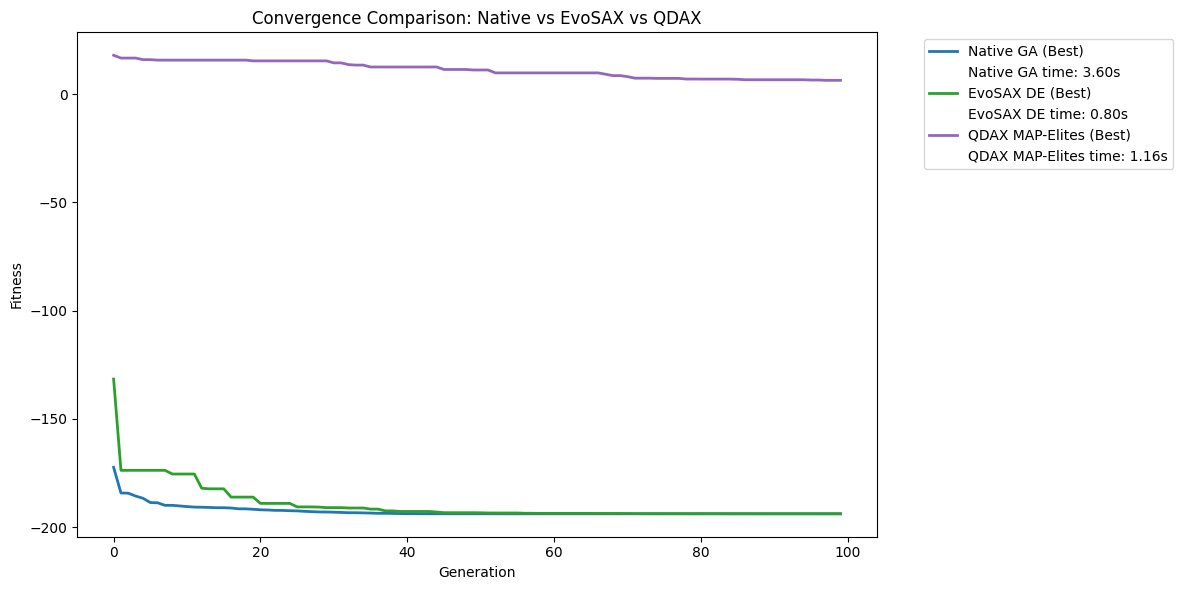

In [4]:
plt.figure(figsize=(12, 6))

for name, result in results.pipelines.items():
    artifact = result.runs[0]
    generations = jnp.arange(len(artifact.history))
    
    best_fitness = jnp.array([h["best_fitness"] for h in artifact.history])
    plt.plot(generations, best_fitness, label=f"{name} (Best)", linewidth=2)
    
    # We can also plot execution time as text in the legend
    plt.plot([], [], ' ', label=f"{name} time: {artifact.duration_seconds:.2f}s")

plt.title("Convergence Comparison: Native vs EvoSAX vs QDAX")
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
import os
os.makedirs("results/showcase", exist_ok=True)
plt.savefig("results/showcase/02_convergence.png")
print("Plot saved to results/showcase/02_convergence.png")
# plt.show() # Uncomment to view interactively

## 4. Inspecting Metrics Dataframes

The metrics are also accessible as raw DataFrames, making it easy to export or analyze them further.

In [5]:
metrics_data = []
for name, result in results.pipelines.items():
    artifact = result.runs[0]
    # Only keep scalar metrics for the dataframe
    row = {"Pipeline": name, "Execution Time (s)": artifact.duration_seconds}
    for k, v in artifact.metrics.items():
        if isinstance(v, (int, float, jnp.ndarray)) and getattr(v, 'ndim', 0) == 0:
            row[k] = float(v)
    metrics_data.append(row)

df = pd.DataFrame(metrics_data)
print("\nFinal Metrics Comparison:")
print(df.to_string(index=False))


Final Metrics Comparison:
       Pipeline  Execution Time (s)  initial_fitness  best_fitness   fitness_auc  final_generation  total_evaluations  gap_to_optimum     qd_score  coverage
      Native GA            3.596413      -145.111984   -193.856583 -19263.182770             100.0             5000.0        0.000153          NaN       NaN
      EvoSAX DE            0.799503              NaN   -193.847733 -18957.402344             100.0             5000.0        0.009003          NaN       NaN
QDAX MAP-Elites            1.155119              NaN      6.382178   1127.776193             100.0             5000.0             NaN -4288.698242      75.0


This concludes the Universal Adapter demonstration! In **03_dynamic_benchmarking.py**, we'll see how we scale this exact comparison into a massive, statistically rigorous multi-seed benchmarking suite using TOML configuration files.